In [1]:
import numpy as np
import matplotlib.pyplot as plt
import h5py
from tqdm import tqdm

In [2]:
indices = [3, 4, 5, 9, 8, 7, 10, ## peninsula
           13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 25, ## west ant
           28, 29, 31, 39, 33, 34, 36, 38, 40, 44, 45,47, ## East Ant
           52, 64, 63, 62, 61, 53, 54, 55, 58, 56, 57, 60, 59,
           26, 27, ## Ross
           11, 65] ## filchner-ronne

# for i in indices: 
#     print(i, Names[i])

In [4]:
## Data from Adusumilli et al. (2020)

Names = ['Larsen D', 'Larsen C', 'Larsen B',
              'George VI', 'Bach', 'Wilkins', 'Stange', 'Venable', 'Abbot',
              'Cosgrove', 'Pine Island', 'Thwaites', 'Crosson', 'Dotson', 'Getz',
              'Land', 'Nickerson', 'Sulzberger', 'Withrow', 'Drygalski', 'Nansen', 'Mariner',
              'Moscow University', 'Rennick', 'Cook', 'Mertz', 'Holmes', 'Totten', 'Shackleton', 'West',
              'Amery',
              'Prince Harald', 'Brunt Stancomb', 'Riiser-Larsen', 'Quar', 'Ekstrom', 'Baudouin', 'Borchgrevink', 'Lazarev', 'Fimbul', 'Nivl', 'Vigrid', 'Atka', 'Jelbart',
              'Ross West', 'Ross East',
              'Ronne', 'Filchner']

Adu_M = [1.8, 2.0 , 2.2,
         4.3, 3.2, 2.7, 3.7, 5.1, 1.5,
        1.0, 14.0, 26.7, 7.8, 5.4, 4.2,
        20.4, 1.2, 1.5, 3.3, 1.9, 1.6, 1.1,
        7.4, 1.9, 1.3, 5.0, 13.3, 11.5, 1.8, 1.4,
        0.8,
        2.3, 0.6, 0.5, 0.4, 1.0, 1.0, 0.8, 0.8, 1.0, 1.1, 1.2, 1.0, 1.0,
         0.3, 0.3,
        0.2,  0.4]

Adu_Merr = [1.9, 2.5, 2.3,
            2.2, 2.1, 3.4, 2.1, 2.0, 1.5, 
           1.5, 1.6, 2.4, 1.8, 1.6, 1.4,
           2.7, 1.4, 1.3, 1.8, 0.9, 1.1, 1.7,
           2.1, 1.4, 1.6, 2.4, 2.9, 2.0, 1.9, 1.8,
           0.7,
           1.9, 0.8, 0.8, 0.8, 1.2, 1.0, 1.0, 0.8, 0.8, 1.1, 1.0, 1.2, 1.1, 
            0.4, 0.4,
           0.4, 0.4]

Adu_GT = [30.8, 77.9, 3.9,
          88.8, 13.1, 26.1, 25.4, 14.3, 37.1,
         2.7, 76.6, 81.9, 20.9, 28.2, 124.1,
         11.0, 6.5, 15.7, 1.0, 3.8, 2.8, 2.3, 
         28.3, 5.5, 3.9, 14.8, 20.9, 64.0, 44.0, 20.1,
         45.6, 
         8.6, 18.0, 19.4, 0.7, 6.4, 28.8, 15.5, 6.3, 36.2, 7.0, 2.3, 1.6, 9.9,
          45.8, 34.3,
         47.2, 34.2]

Adu_GTerr = [31.3, 98.7, 4.2,
             45.7, 8.5, 32.0, 14.2, 5.5, 38.1,
            4.1, 8.6, 7.4, 4.9, 8.5, 40.9,
            1.5, 7.9, 13.3, 0.6, 1.7, 1.8, 3.6,
            8.0, 3.9, 5.1, 7.1, 4.5, 11.0, 44.8, 25.1, 
            40.0,
            7.2, 24.6, 30.0, 1.6, 7.2, 29.1, 20.3, 6.2, 29.0, 7.2, 1.8, 1.9, 11.3,
             68.3, 45.2,
            119.3, 29.6]

Adu_Area = [18282, 42384, 1985,
            22755, 4444, 10390, 7397, 3037, 27461,
            2964, 5950, 3352, 2932, 5657, 32114,
            587, 6001, 11229, 341, 2168, 1835, 2354,
            4145, 3123, 3408, 3243, 1717, 6078, 26182, 15306,
            60228,
            4067, 34573, 42644, 2076, 6754, 32789, 21368, 8456, 40600, 7275, 2071, 1780, 10756,
             198293, 135261,
            311968, 83304]

# for i in range(len(IceShelves)):
#     print(f"\n{IceShelves[i]}: {Adu_GT[i]} ± {Adu_GTerr[i]}")

In [5]:
## Data from Rignot et al. (2013)

Rignot_Names = ["Larsen G", "Larsen F","Larsen E","Larsen D", "Larsen C","Larsen B","Wordie","Wilkins",
       "Bach","George VI","Stange",  "Ronne","Ferrigno","Venable",
       "Abbot","Cosgrove","Pine Island","Thwaites","Crosson","Dotson",
       "Getz","Land","Nickerson","Sulzberger","Swinburne","Withrow","Ross West","Ross East", "Drygalski","Nansen",
       "Aviator","Mariner","Lillie","Rennick","Cook","Ninnis","Mertz","Dibble","Holmes","Moscow University","Totten",
       "Vincennes","Conger_Glenzer","Tracy_Tremenchus","Shackleton","West","Publications","Amery",
       "Wilma_Robert_Downer","Edward VIII","Rayner_Thyer","Shirase","Prince Harald","Baudouin",
       "Borchgrevink","Lazarev","Nivl","Vigrid","Fimbul","Jelbart","Atka","Ekstrom","Quar","Riiser-Larsen",
       "Brunt_Stancomb","Filchner"]

MR_meters = [0.71, 1.4, 1.2, 0.1, 0.4, 1.8, 23.6, 1.5, 2.3, 3.8, 3.5, 0.3, 43.4, 6.1, 1.7, 2.8, 16.2,
      17.7, 11.9, 7.8, 4.3, 5.9, 0.6, 1.5, 4.2, 0.5, 0, 0.3, 3.3, 0.6, 1.7, 0.9, 4.4, 2.2, 1.3, 1.2,
      1.4, 5.5, 3.5, 4.7, 10.5, 5.3, 2.3, 1.5, 2.8, 1.7, 1.0, 0.6, 11.7, 10.2, 10.5, 7.0, -0.4, 0.4,
      0.3, 0.7, 0.5, 1.5, 0.6, -0.1, -0.2, 0.6, 0.7, 0.2, 0.03, 0.4]

MR_meters_Error = [0.6, 0.5, 0.9, 0.6, 1, 2, 10, 1, 0.3, 0.7, 0.7, 0.1, 17, 0.7, 0.6, 0.7, 1, 1, 1,
      0.6, 0.4, 2, 0.3, 0.3, 0.6, 0.6, 0.1, 0.1, 0.5, 0.3, 0.3, 0.2, 0.4, 0.3, 1, 2, 0.6, 0.9,
      2, 0.8, 0.7, 2, 0.9, 0.7, 0.6, 0.7, 1, 0.4, 0.7, 2, 2, 2, 0.6, 0.4, 0.3, 0.2, 0.2, 0.3, 0.2,
      0.3, 0.2, 0.2, 0.2, 0.2, 0.2, 0.1]

MR_Mass = [0.3, 1.2, 1.4, 1.4, 20.7, 12.2, 6.5, 18.4, 10.4, 89.0, 28.0, 113.5, 5.1, 19.4, 51.8, 8.5, 101.2,
       97.5, 38.5, 45.2, 144.9, 3.8, 4.2, 18.2, 3.8, 0.3, -1.4, 49.1, 7.6, 1.1, 1.4, 2.4, 3.4, 7.0, 4.6,
       2.2, 7.9, 8.1, 6.7, 27.4, 63.2, 5.0, 3.6, 3.0, 72.6, 27.2, 1.5, 35.5, 10.0, 4.2, 6.7, 5.7, -2.0,
       14.1, 7.5, 6.3, 3.9, 3.2, 23.5, -1.0, -0.5, 4.3, 1.4, 8.7, 1.0, 41.9]

MR_Mass_Error = [0.2, 0.4, 1, 14, 67, 14, 3, 17, 1, 17, 6, 35, 2, 2, 19, 2, 8, 7, 4, 4, 14, 1, 2, 3,
      .5, .4, 20, 14, 1, 0.6, 0.2, 0.6, 0.3, 1, 5, 3, 3, 1, 4, 4, 4, 2, 1, 2, 15, 10, 2, 23, 0.6, 0.8,
      1, 1, 3, 12, 6, 2, 2, 0.7, 9, 3, 0.4, 2, 0.5, 9, 7, 10]

for i in range(len(Rignot_Names)):
    print(f"{Rignot_Names[i]}: {MR_meters[i]} ± {MR_meters_Error[i]}")

Larsen G: 0.71 ± 0.6
Larsen F: 1.4 ± 0.5
Larsen E: 1.2 ± 0.9
Larsen D: 0.1 ± 0.6
Larsen C: 0.4 ± 1
Larsen B: 1.8 ± 2
Wordie: 23.6 ± 10
Wilkins: 1.5 ± 1
Bach: 2.3 ± 0.3
George VI: 3.8 ± 0.7
Stange: 3.5 ± 0.7
Ronne: 0.3 ± 0.1
Ferrigno: 43.4 ± 17
Venable: 6.1 ± 0.7
Abbot: 1.7 ± 0.6
Cosgrove: 2.8 ± 0.7
Pine Island: 16.2 ± 1
Thwaites: 17.7 ± 1
Crosson: 11.9 ± 1
Dotson: 7.8 ± 0.6
Getz: 4.3 ± 0.4
Land: 5.9 ± 2
Nickerson: 0.6 ± 0.3
Sulzberger: 1.5 ± 0.3
Swinburne: 4.2 ± 0.6
Withrow: 0.5 ± 0.6
Ross West: 0 ± 0.1
Ross East: 0.3 ± 0.1
Drygalski: 3.3 ± 0.5
Nansen: 0.6 ± 0.3
Aviator: 1.7 ± 0.3
Mariner: 0.9 ± 0.2
Lillie: 4.4 ± 0.4
Rennick: 2.2 ± 0.3
Cook: 1.3 ± 1
Ninnis: 1.2 ± 2
Mertz: 1.4 ± 0.6
Dibble: 5.5 ± 0.9
Holmes: 3.5 ± 2
Moscow University: 4.7 ± 0.8
Totten: 10.5 ± 0.7
Vincennes: 5.3 ± 2
Conger_Glenzer: 2.3 ± 0.9
Tracy_Tremenchus: 1.5 ± 0.7
Shackleton: 2.8 ± 0.6
West: 1.7 ± 0.7
Publications: 1.0 ± 1
Amery: 0.6 ± 0.4
Wilma_Robert_Downer: 11.7 ± 0.7
Edward VIII: 10.2 ± 2
Rayner_Thyer: 10.5 ± 2


In [6]:
for i in range(len(indices)):
    print(f"{Names[i]}: {Rignot_Names[indices[i]]} ")

Larsen D: Larsen D 
Larsen C: Larsen C 
Larsen B: Larsen B 
George VI: George VI 
Bach: Bach 
Wilkins: Wilkins 
Stange: Stange 
Venable: Venable 
Abbot: Abbot 
Cosgrove: Cosgrove 
Pine Island: Pine Island 
Thwaites: Thwaites 
Crosson: Crosson 
Dotson: Dotson 
Getz: Getz 
Land: Land 
Nickerson: Nickerson 
Sulzberger: Sulzberger 
Withrow: Withrow 
Drygalski: Drygalski 
Nansen: Nansen 
Mariner: Mariner 
Moscow University: Moscow University 
Rennick: Rennick 
Cook: Cook 
Mertz: Mertz 
Holmes: Holmes 
Totten: Totten 
Shackleton: Shackleton 
West: West 
Amery: Amery 
Prince Harald: Prince Harald 
Brunt Stancomb: Brunt_Stancomb 
Riiser-Larsen: Riiser-Larsen 
Quar: Quar 
Ekstrom: Ekstrom 
Baudouin: Baudouin 
Borchgrevink: Borchgrevink 
Lazarev: Lazarev 
Fimbul: Fimbul 
Nivl: Nivl 
Vigrid: Vigrid 
Atka: Atka 
Jelbart: Jelbart 
Ross West: Ross West 
Ross East: Ross East 
Ronne: Ronne 
Filchner: Filchner 


In [7]:
## Copy data from Rignot et al. (2013) in the correct order
Rig_M = []
Rig_Merr = []

Rig_GT = []
Rig_GTerr = []

for i in indices:
    Rig_M.append(MR_meters[i])
    Rig_Merr.append(MR_meters_Error[i])

    Rig_GT.append(MR_Mass[i])
    Rig_GTerr.append(MR_Mass_Error[i])

In [8]:
## Load SOhi v2 melt rates 
SOhi_data = np.load('Data/melt_rates/SOhi-v2/SOhi_v2_OctNovDec2007_MR.npy')
SOhi_ID_mask = np.load("Data/masks/SOhi_ID_mask.npy")
SOhi_ID_mask = SOhi_ID_mask[:2344, :]

GRID = h5py.File('Data/SOhi_meta/SOhi_v1_GRID_v8.mat')
XC = np.asarray(GRID['XC'][0,:])
XC = ((XC + 180) %360) - 180

YC = np.asarray(GRID['YC'][:2344,0])
AREA = np.asarray(GRID['aRAC'][:2344,:])

In [9]:
### Calculate melt rates in m/yr and Gt/yr for ice shelves in list 
SOhi_M = []
SOhi_GT = []

counter = 0
for index in indices:
    temp = np.ones((2344, 8640))
    temp[SOhi_ID_mask != index] = np.nan
    TOTAL_Melt = np.nansum(-SOhi_data * temp * AREA * 60 * 60 * 24* 365) ## kg
    
    SOhi_GT.append(TOTAL_Melt / 1e12)
    
    TOTAL_Area = np.nansum(AREA * temp)
    val = TOTAL_Melt / TOTAL_Area / 917 ## kg/yr * 1/m^2 * m^3/kg -> m/yr 
    SOhi_M.append(val)

    count = np.count_nonzero(temp == 1)
    # print(f"{index} ({counter}) - {Names[index]} ({count}): {val:0.2f}") 
    counter += 1

/var/folders/f8/s61qdz9n3pz5knzrxfklfwlh0000gn/T/ipykernel_49549/2581699994.py:14: RuntimeWarning: invalid value encountered in scalar divide
  val = TOTAL_Melt / TOTAL_Area / 917 ## kg/yr * 1/m^2 * m^3/kg -> m/yr


In [11]:
cur = 49
for i in range(48):
    # if i == 25: ## withrow
    #     continue

    print(f'{Names[i]}: {SOhi_M[i]}')

Larsen D: 0.7424336621186578
Larsen C: 0.7422083978870792
Larsen B: 0.7745465243582486
George VI: 9.38149674776382
Bach: 7.025869413663503
Wilkins: 4.319303789677042
Stange: 10.11294002238484
Venable: 13.332197928425954
Abbot: 6.272851556687289
Cosgrove: 9.555899789441748
Pine Island: 28.144115700411042
Thwaites: 28.40536478663225
Crosson: 26.903816823750592
Dotson: 36.042950143228815
Getz: 21.74395938831747
Land: 44.41588491021234
Nickerson: 6.975527894431575
Sulzberger: 13.716471529031258
Withrow: nan
Drygalski: 6.744055764058544
Nansen: 1.561286949565102
Mariner: 5.036671560581014
Moscow University: 26.900287486964885
Rennick: 7.28952339934717
Cook: 8.391824463600884
Mertz: 11.59239786720668
Holmes: 3.8574289478099395
Totten: 24.92320886528161
Shackleton: 2.5246678276735293
West: 3.6672724155026235
Amery: 10.430803767804976
Prince Harald: 0.9091126652828625
Brunt Stancomb: 0.9414725179252919
Riiser-Larsen: 0.5786140454397937
Quar: 1.487854703088383
Ekstrom: 2.256783183278376
Baudoui

In [30]:
SOhi_Std = [0.15513029934542835,
            0.11213338173221479,
0.06911182748917208,
0.4084478064092223,
0.506402403073582,
0.33736933352721454,
0.5603390971823579,
3.0037598003864168,
0.44651263182878775,
0.8115193069606272,
1.1428995604616312,
2.667884138747588,
2.4640262449703547,
1.751077243470239,
1.2121653788776177,
3.4287076959295093,
0.7220747597577297,
0.56599466831805,
np.nan,
0.5005940697549146,
0.2249432080283937,
0.40465992141019774,
1.244357771907861,
0.3684669735062819,
0.6848061363832969,
0.9944817639178634,
0.3097891975639198,
1.8713639564093218,
0.42005621709294233,
0.4144403954333687,
0.6761169148190656,
0.047337596904415725,
0.09399425474961132,
0.08799758908970429,
0.18880233421187395,
0.230117997426199,
0.1960030771297359,
0.20266002641844422,
0.1502638580841861,
0.14600726216435503,
0.2469170088952869,
0.6182601393765224,
0.19889806594530293,
0.4457546832390311,
0.12359668214900311,
0.11217529553980238,
0.13793330456412245,
0.9433663716567964]

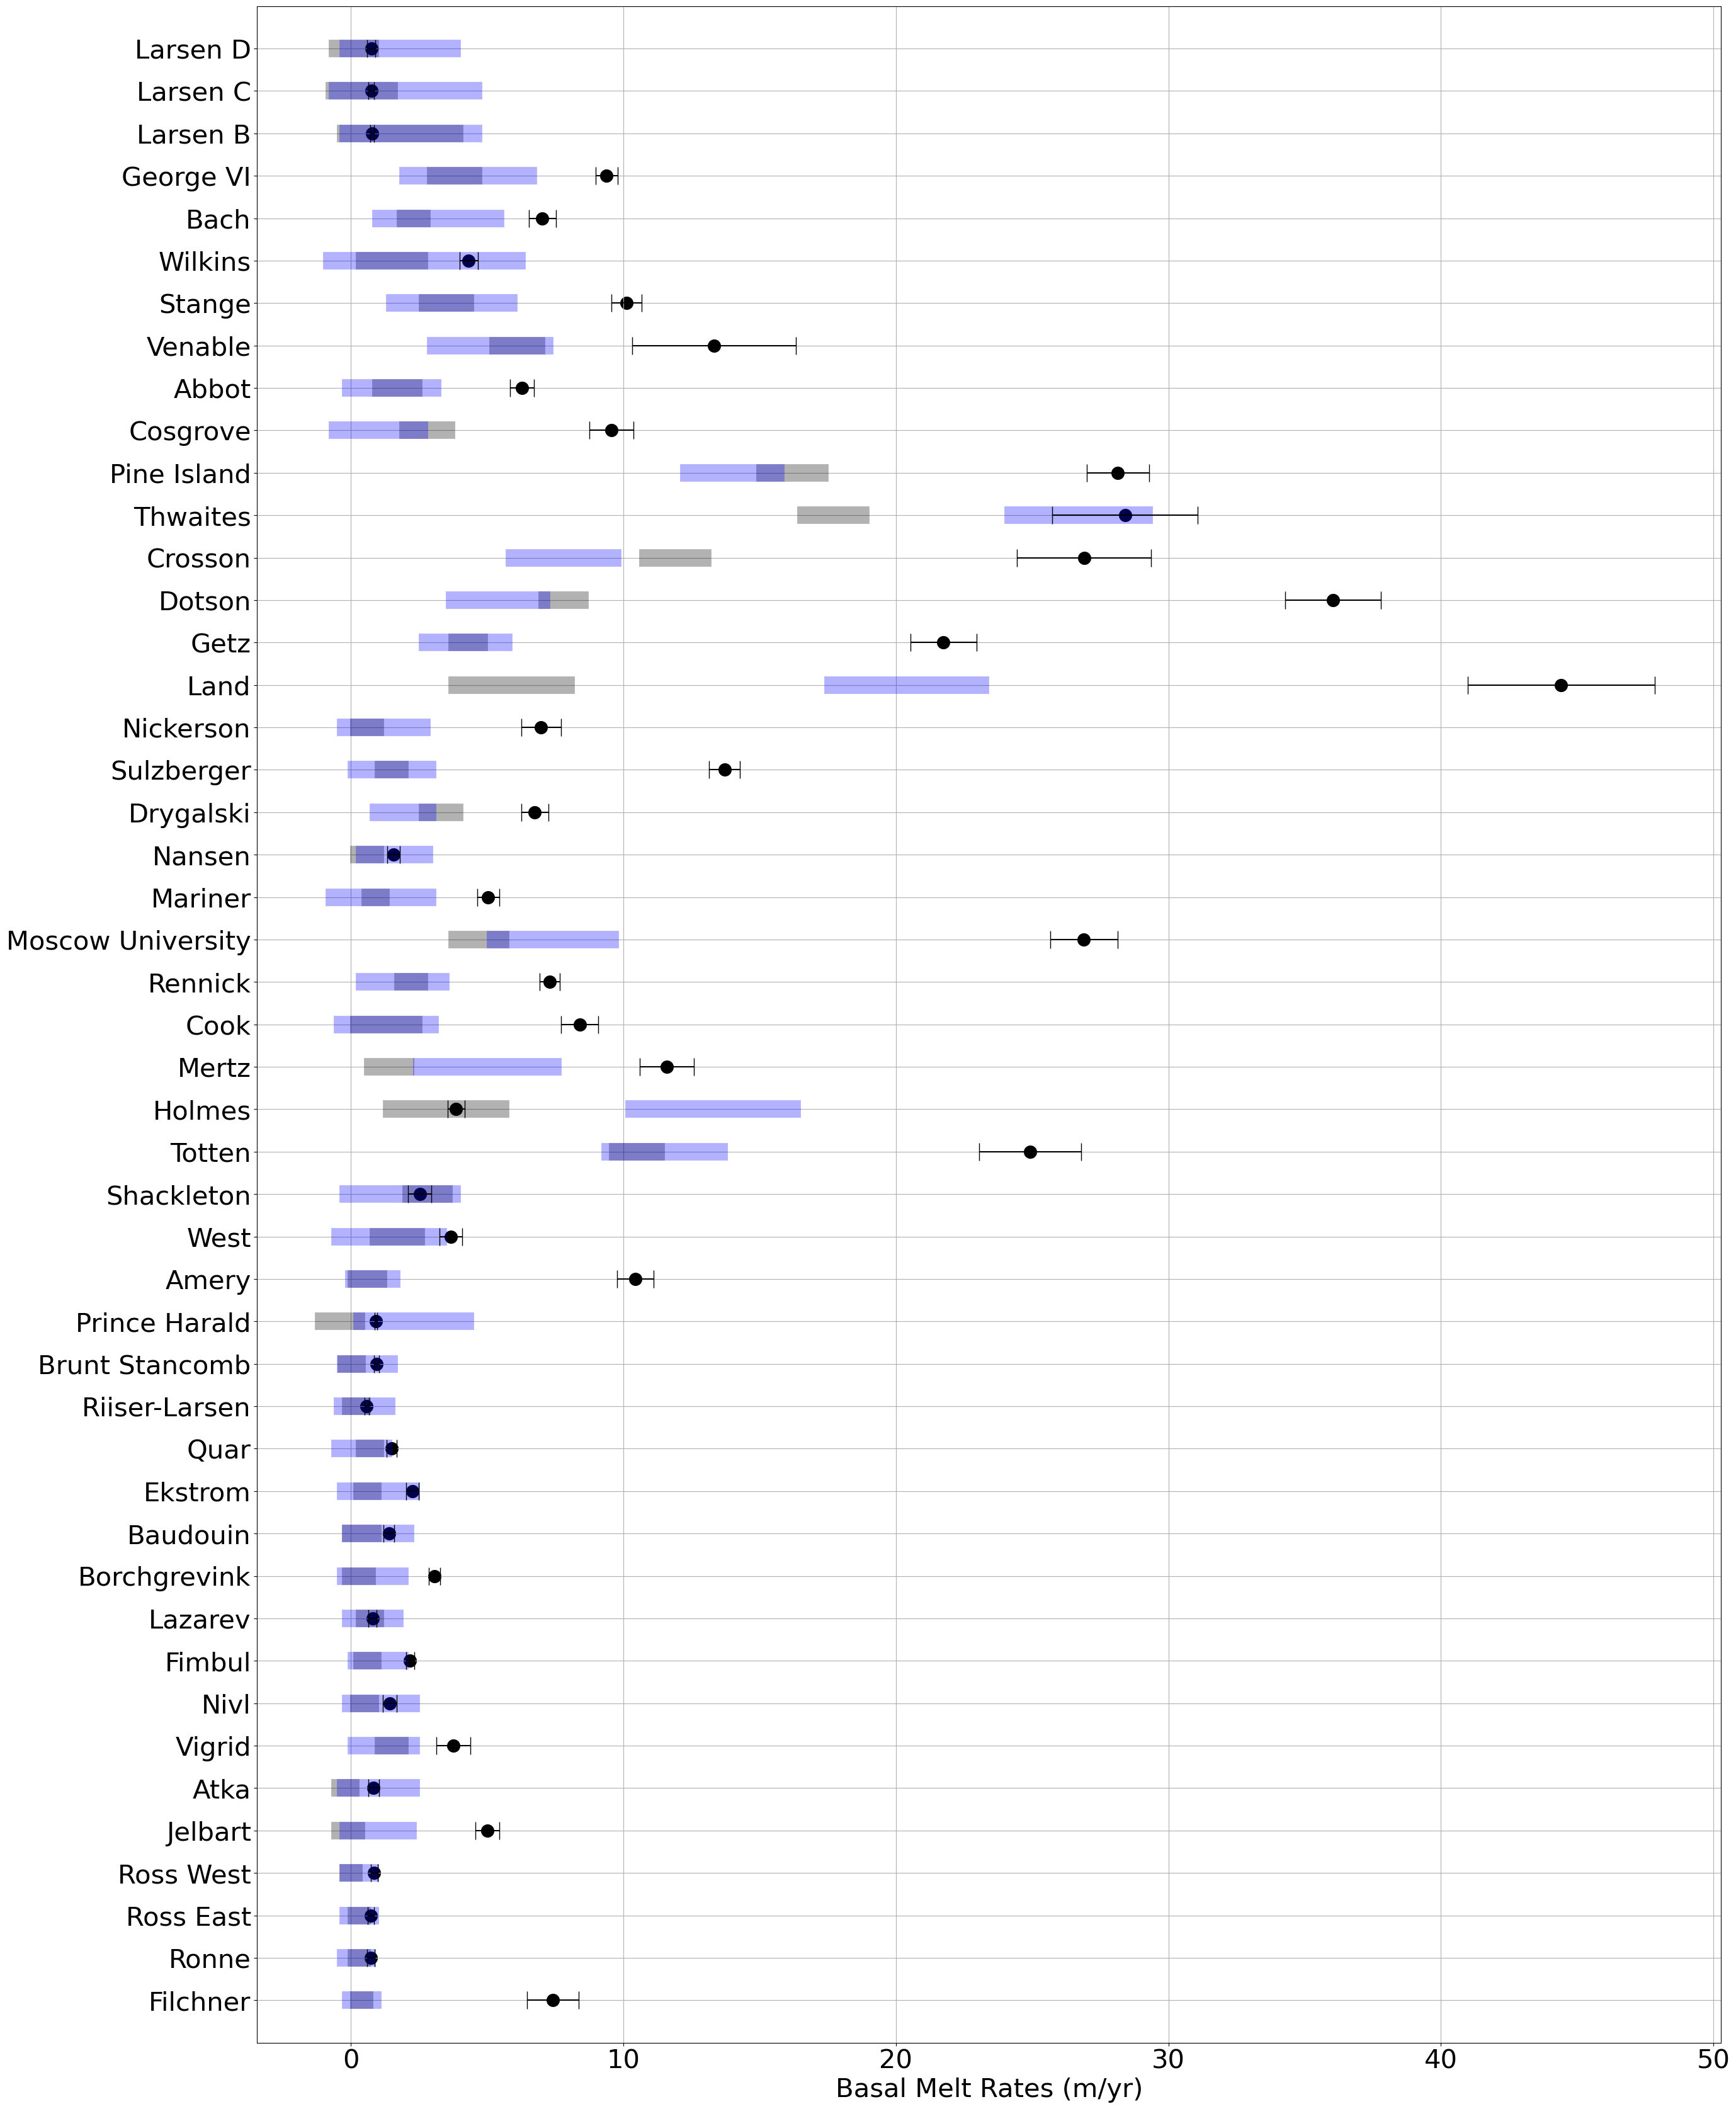

In [37]:
fig, ax = plt.subplots(figsize=(30, 42))

cur = 49
for i in range(48):
    if i == 18: ## withrow
        continue

    ax.plot([Rig_M[i] - Rig_Merr[i], Rig_M[i] + Rig_Merr[i]], [cur,cur], 
            lw= 20, c='k', alpha=0.3)
    ax.plot([Adu_M[i] - Adu_Merr[i], Adu_M[i] + Adu_Merr[i]], [cur,cur], 
            lw= 20, c='b', alpha=0.3)

    ax.scatter(SOhi_M[i], cur, marker='o', s=200, c='k')
    ax.errorbar(SOhi_M[i], cur, xerr = SOhi_Std[i], c='k', capsize=10)

    cur -=1

IS_Names = [Names[i] for i in range(len(Names)) if i != 18]
IS_Names = IS_Names[::-1]
ax.set_yticks(np.arange(3, 50, 1))
ax.set_yticklabels(np.asarray(IS_Names[:]), fontsize=30)
ax.set_ylim(2, 50)
ax.grid()

ax.tick_params(axis='x', labelsize=30)
ax.set_xlabel('Basal Melt Rates (m/yr)', fontsize=30)

plt.savefig('Figures/Fig03/source.png', dpi=300)

In [38]:
SOhi_Std = [3.0825376645717095,
4.715796060242074,
0.12168439875823776,
8.610140115358856,
2.0606460180669193,
3.2229755031196596,
4.008371713660194,
8.530031802130576,
11.82470320995365,
2.2256356172268883,
6.379726564129287,
8.353747194622946,
7.226336025937224,
9.316793009311857,
36.437095210639605,
1.865713041086523,
4.026640619651099,
6.250836606542951,
0.0,
1.0182779758652591,
0.3980670325977934,
0.8768022313294725,
6.497964665491538,
1.0800355040023797,
1.9631844669138394,
2.8647082434152407,
0.5633153055672868,
10.47629820903982,
9.709259338626545,
5.5343219040521285,
36.83354107739941,
0.20782557413419508,
3.092819375575859,
3.4750885174179986,
0.3625909194723516,
1.4274250594862816,
5.841657969588708,
3.8245724623246815,
1.1535135607281646,
5.392422510015482,
1.6428147107597033,
1.161376212850837,
0.33408709907869627,
4.3618103409929745,
34.233499292526474,
19.708466961661337,
42.18389028795179,
88.28340463469694]

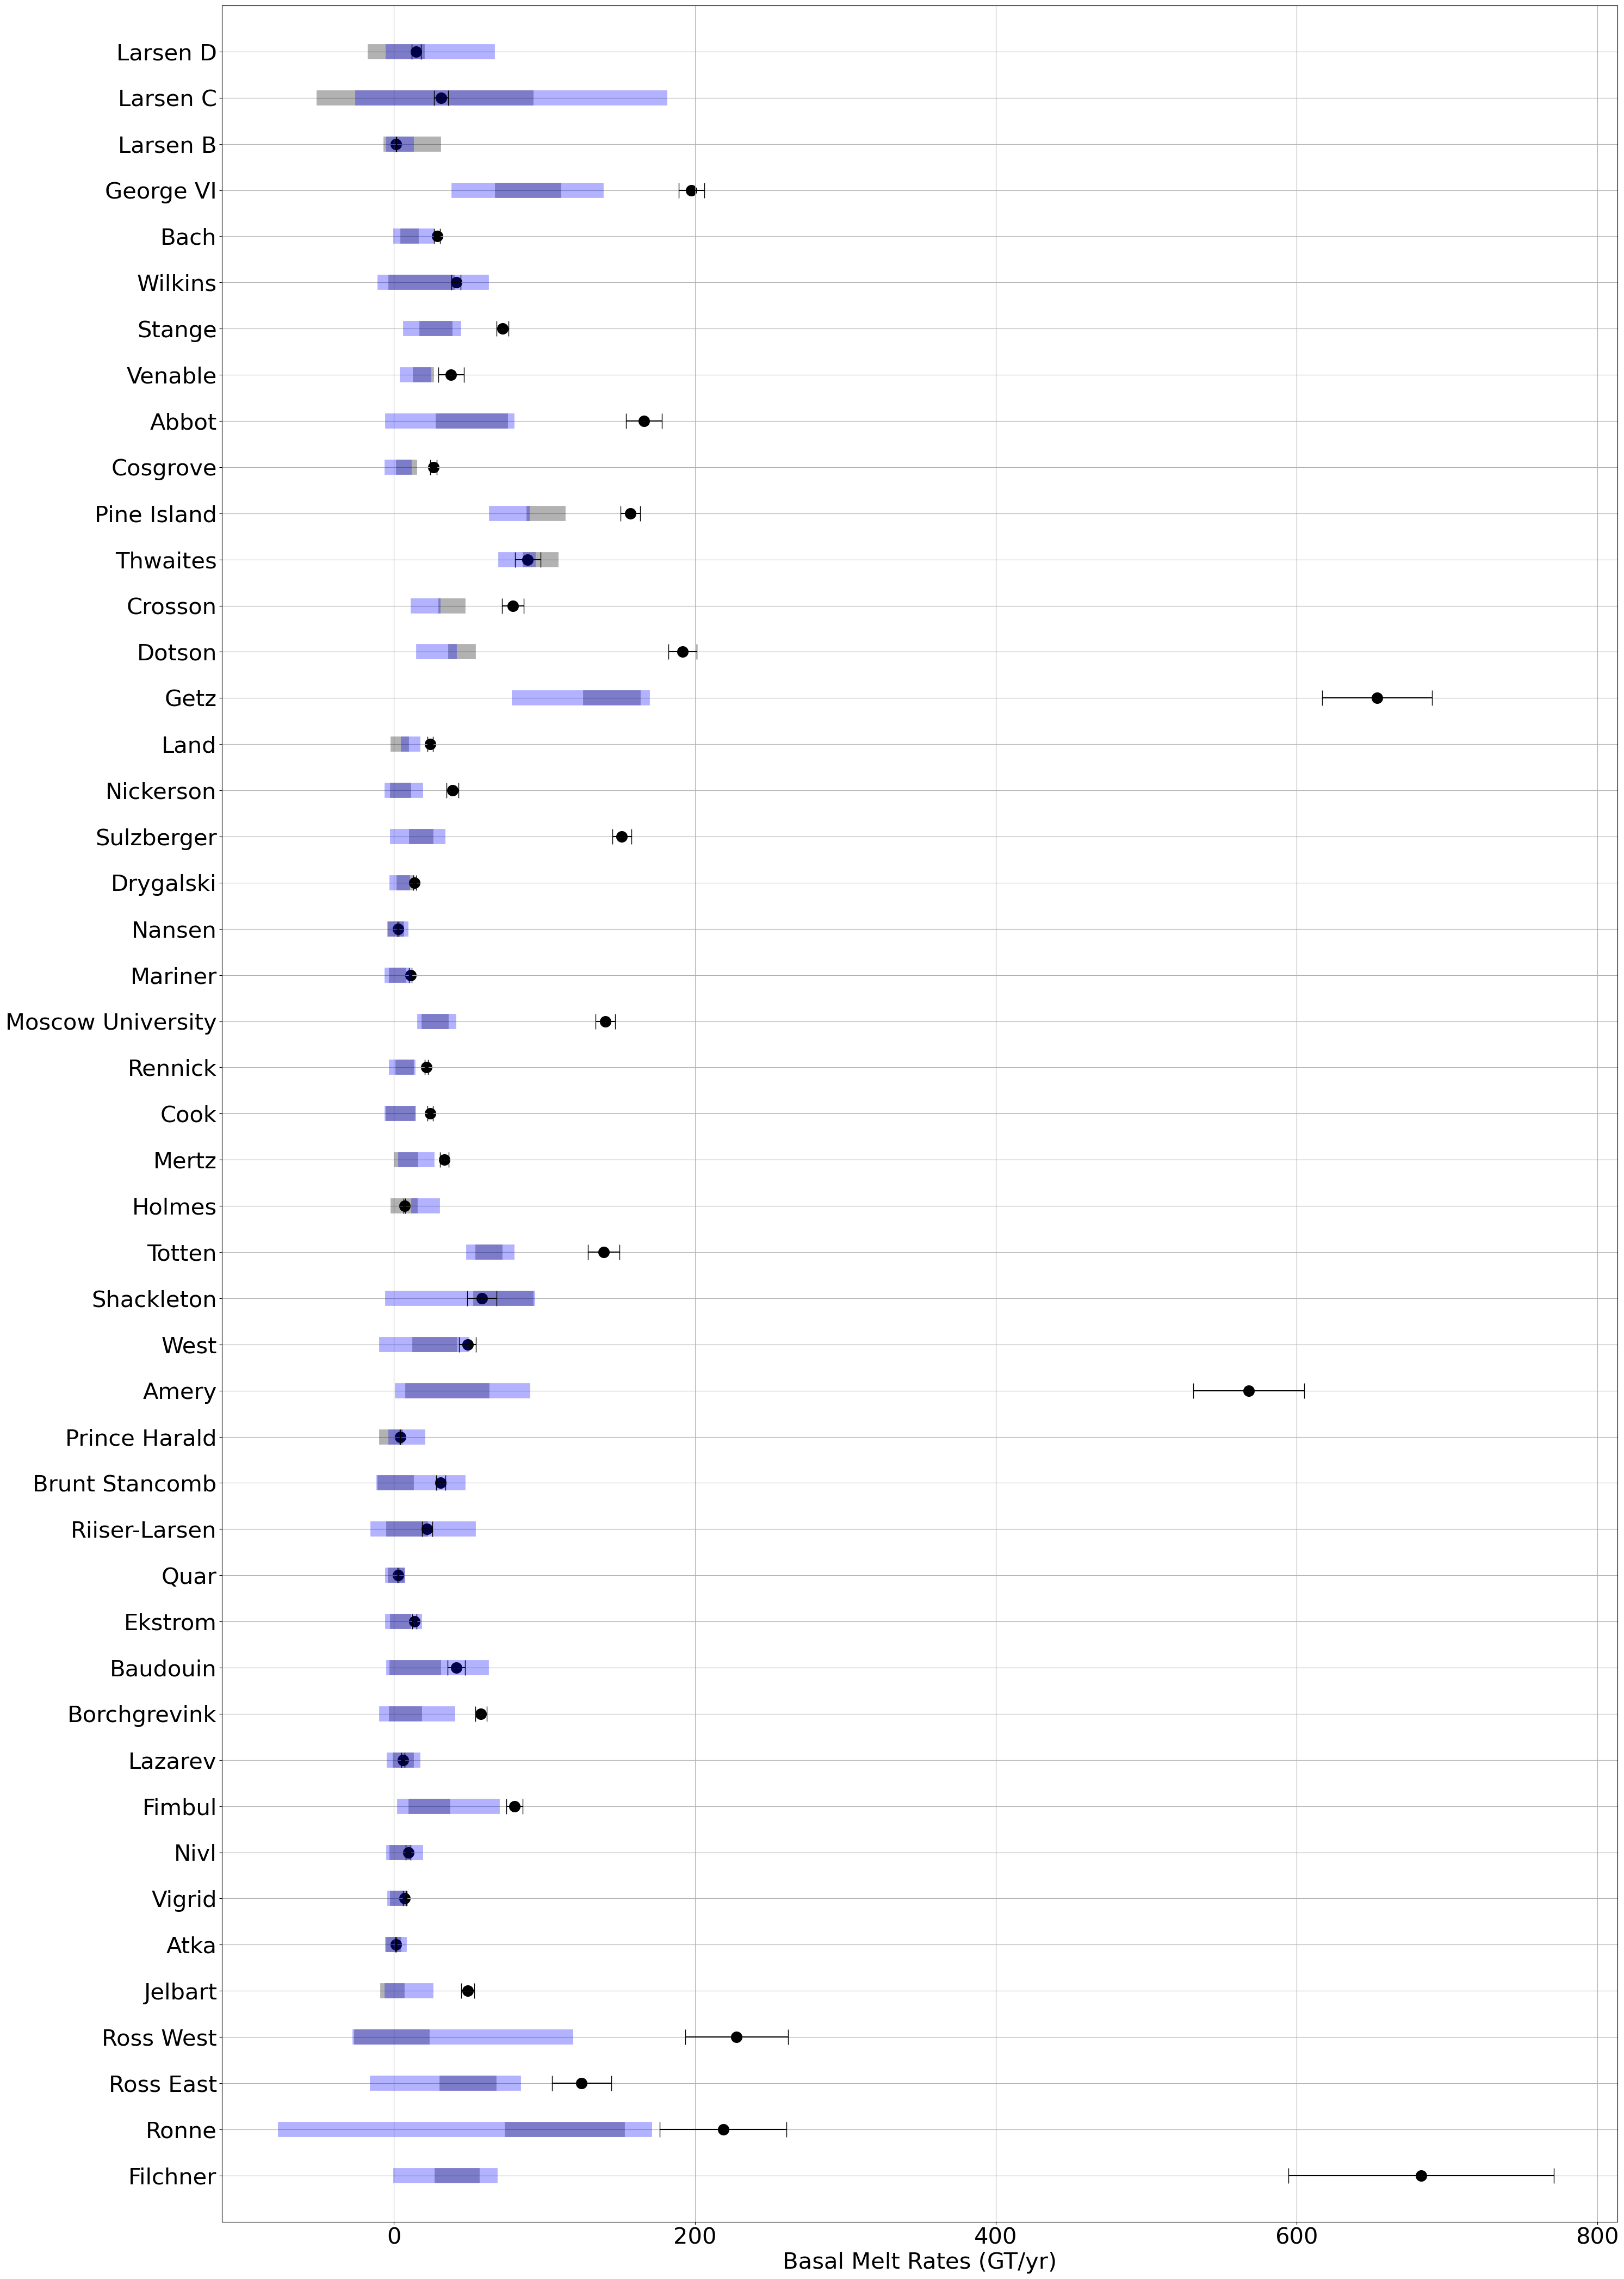

In [43]:
fig, ax = plt.subplots(figsize=(30, 42))

cur = 49
for i in range(48):
    if i == 18: ## withrow
        continue

    ax.plot([Rig_GT[i] - Rig_GTerr[i], Rig_GT[i] + Rig_GTerr[i]], [cur,cur], 
            lw= 20, c='k', alpha=0.3)
    ax.plot([Adu_GT[i] - Adu_GTerr[i], Adu_GT[i] + Adu_GTerr[i]], [cur,cur], 
            lw= 20, c='b', alpha=0.3)

    ax.scatter(SOhi_GT[i], cur, marker='o', s=200, c='k')
    ax.errorbar(SOhi_GT[i], cur, xerr = SOhi_Std[i], c='k', capsize=10)

    cur -=1

IS_Names = [Names[i] for i in range(len(Names)) if i != 18]
IS_Names = IS_Names[::-1]
ax.set_yticks(np.arange(3, 50, 1))
ax.set_yticklabels(np.asarray(IS_Names[:]), fontsize=30)
ax.set_ylim(2, 50)
ax.grid()

ax.tick_params(axis='x', labelsize=30)
ax.set_xlabel('Basal Melt Rates (GT/yr)', fontsize=30)

    # ax.set_xscale('log')
plt.tight_layout()
plt.savefig('Figures/S03/source.png', dpi=300)

In [103]:
hcount = 0
lcount = 0
gcount = 0

for i in range(48):
    if i == 25:
        continue
    MIN = min([Rig_GT[i] - Rig_GTerr[i], Adu_GT[i] - Adu_GTerr[i]])
    MAX = max([Rig_GT[i] + Rig_GTerr[i], Adu_GT[i] + Adu_GTerr[i]])
    if SOhi_GT[i] <= MIN:
        print(f"{IceShelves[i]}: LOW {MIN:0.1f}, {MAX:0.1f}, {SOhi_GT[i]:0.1f}")
        lcount+=1 
    elif SOhi_GT[i] >= MAX:
        print(f"{IceShelves[i]}: HIGH {MIN:0.1f}, {MAX:0.1f}, {SOhi_GT[i]:0.1f}")
        hcount+=1
    else:
        print(f"{IceShelves[i]}: GOOD {MIN:0.1f}, {MAX:0.1f}, {SOhi_GT[i]:0.1f}")
        gcount+=1

print(hcount, lcount, gcount)

Larsen D: GOOD -12.6, 62.1, 14.8
Larsen C: GOOD -46.3, 176.6, 31.2
Larsen B: GOOD -1.8, 26.2, 1.4
George VI: HIGH 43.1, 134.5, 197.8
Bach: HIGH 4.6, 21.6, 28.6
Wilkins: GOOD -5.9, 58.1, 41.3
Stange: HIGH 11.2, 39.6, 72.1
Venable: HIGH 8.8, 21.4, 37.9
Abbot: HIGH -1.0, 75.2, 166.1
Cosgrove: HIGH -1.4, 10.5, 26.2
Pine Island: HIGH 68.0, 109.2, 157.1
Thwaites: GOOD 74.5, 104.5, 88.9
Crosson: HIGH 16.0, 42.5, 78.9
Dotson: HIGH 19.7, 49.2, 191.8
Getz: HIGH 83.2, 165.0, 653.6
Land: HIGH 2.8, 12.5, 24.2
Nickerson: HIGH -1.4, 14.4, 38.9
Sulzberger: HIGH 2.4, 29.0, 151.5
Withrow: GOOD -0.1, 1.6, 0.0
Drygalski: HIGH 2.1, 8.6, 13.7
Nansen: GOOD 0.5, 4.6, 2.8
Mariner: HIGH -1.3, 5.9, 10.9
Moscow University: HIGH 20.3, 36.3, 140.5
Rennick: HIGH 1.6, 9.4, 21.4
Cook: HIGH -1.2, 9.6, 24.1
Holmes: GOOD 2.7, 25.4, 7.0
Totten: HIGH 53.0, 75.0, 139.5
Shackleton: GOOD -0.8, 88.8, 58.4
West: HIGH -5.0, 45.2, 48.9
Amery: HIGH 5.6, 85.6, 568.3
Prince Harald: GOOD -5.0, 15.8, 4.0
Brunt Stancomb: GOOD -6.6, 42.

In [104]:
ERR_Rignot = []
ERR_ADU = []

for i in range(48):
    ERR_Rignot.append(SOhi_GT[i] - Rig_GT[i])
    ERR_ADU.append(SOhi_GT[i] - Adu_GT[i])

ERR_Rignot = np.asarray(ERR_Rignot)
ERR_ADU = np.asarray(ERR_ADU)

In [105]:
sort_index1 = np.argsort(ERR_Rignot)[::-1]
sort_index2 = np.argsort(ERR_ADU)[::-1]

for i in range(5):
    print(f"{IceShelves[sort_index1[i]]} ({ERR_Rignot[sort_index1[i]]:0.2f}), {IceShelves[sort_index2[i]]} ({ERR_ADU[sort_index2[i]]:0.2f})")

Filchner (641.03), Filchner (648.73)
Amery (532.75), Getz (529.51)
Getz (508.71), Amery (522.65)
Ross West (229.21), Ross West (182.01)
Dotson (146.57), Ronne (171.68)


In [106]:
for i in range(5):
    print(f"{IceShelves[sort_index1[i]]} : {SOhi_GT[sort_index1[i]]:0.0f}, {Rig_GT[sort_index1[i]]:0.0f}")
    print(f"{IceShelves[sort_index2[i]]} : {SOhi_GT[sort_index2[i]]:0.0f}, {Adu_GT[sort_index2[i]]:0.0f}")
    print()

Filchner : 683, 42
Filchner : 683, 34

Amery : 568, 36
Getz : 654, 124

Getz : 654, 145
Amery : 568, 46

Ross West : 228, -1
Ross West : 228, 46

Dotson : 192, 45
Ronne : 219, 47



In [107]:
rcount = 0
acount = 0

for i in range(10):
    rcount += ERR_Rignot[sort_index1[i]]
    acount += ERR_ADU[sort_index2[i]]

print(rcount, acount)

2633.087020547474 2704.0870205474735


In [108]:
2633 / 3289, 2704/3529


(0.8005472788081484, 0.7662227259846982)